# Spatial Visuals Plots
Only on human lung samples

In [1]:
from tifffile import imread
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns
from itertools import combinations
import os 
os.makedirs('spatial_visual', exist_ok=True)
import anndata
from sklearn.cluster import KMeans
import numpy as np
import scanpy as sc
from shapely import wkt
from shapely.geometry import Point, box
import skimage.filters

In [2]:
method_map = {
    'naive_8um_cyto': 'Naive 8μm',
    'stardist_proximity_cyto': 'StarDist + Proximity',
    'stardist_voronoi_cyto': 'StarDist + Mask + Voronoi',
    'stardist_nuclei': 'StarDist Nuclei',
    'cellpose_proximity_cyto': 'Cellpose + Proximity',
    'cellpose_voronoi_cyto': 'Cellpose + Mask + Voronoi',
    'cellpose_cyto': 'Cellpose3 Cytoplasm',
    'cellpose_nuclei': 'Cellpose Nuclei',
    'bin2cell_cyto': 'Bin2Cell Cytoplasm',
    'STP_tuned_cyto': 'STP Tuned',
    'STP_untuned_cyto': 'STP Untuned',
}

In [3]:
path = '/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/analysis/human_lung/human_lung_run'

data = {}
for seg in method_map.keys():
    gdf = gpd.read_file(f"{path}/{seg}.gpkg")
    
    data[seg] = gdf

In [4]:
# image info
img = imread('/uufs/chpc.utah.edu/common/home/u1531817/20250523_cell_seg_eval/data/human_lung/Visium_HD_Human_Lung_Cancer_HD_Only_Experiment1_tissue_image.btf')
microns_per_pixel = 0.2737554241192739 # from Visium metadata
region_x=[9000, 11000]
region_y=[9000, 11000]
region_box = box(region_x[0], region_y[0], region_x[1], region_y[1])
img_region = img[region_y[0]:region_y[1], region_x[0]:region_x[1], :]

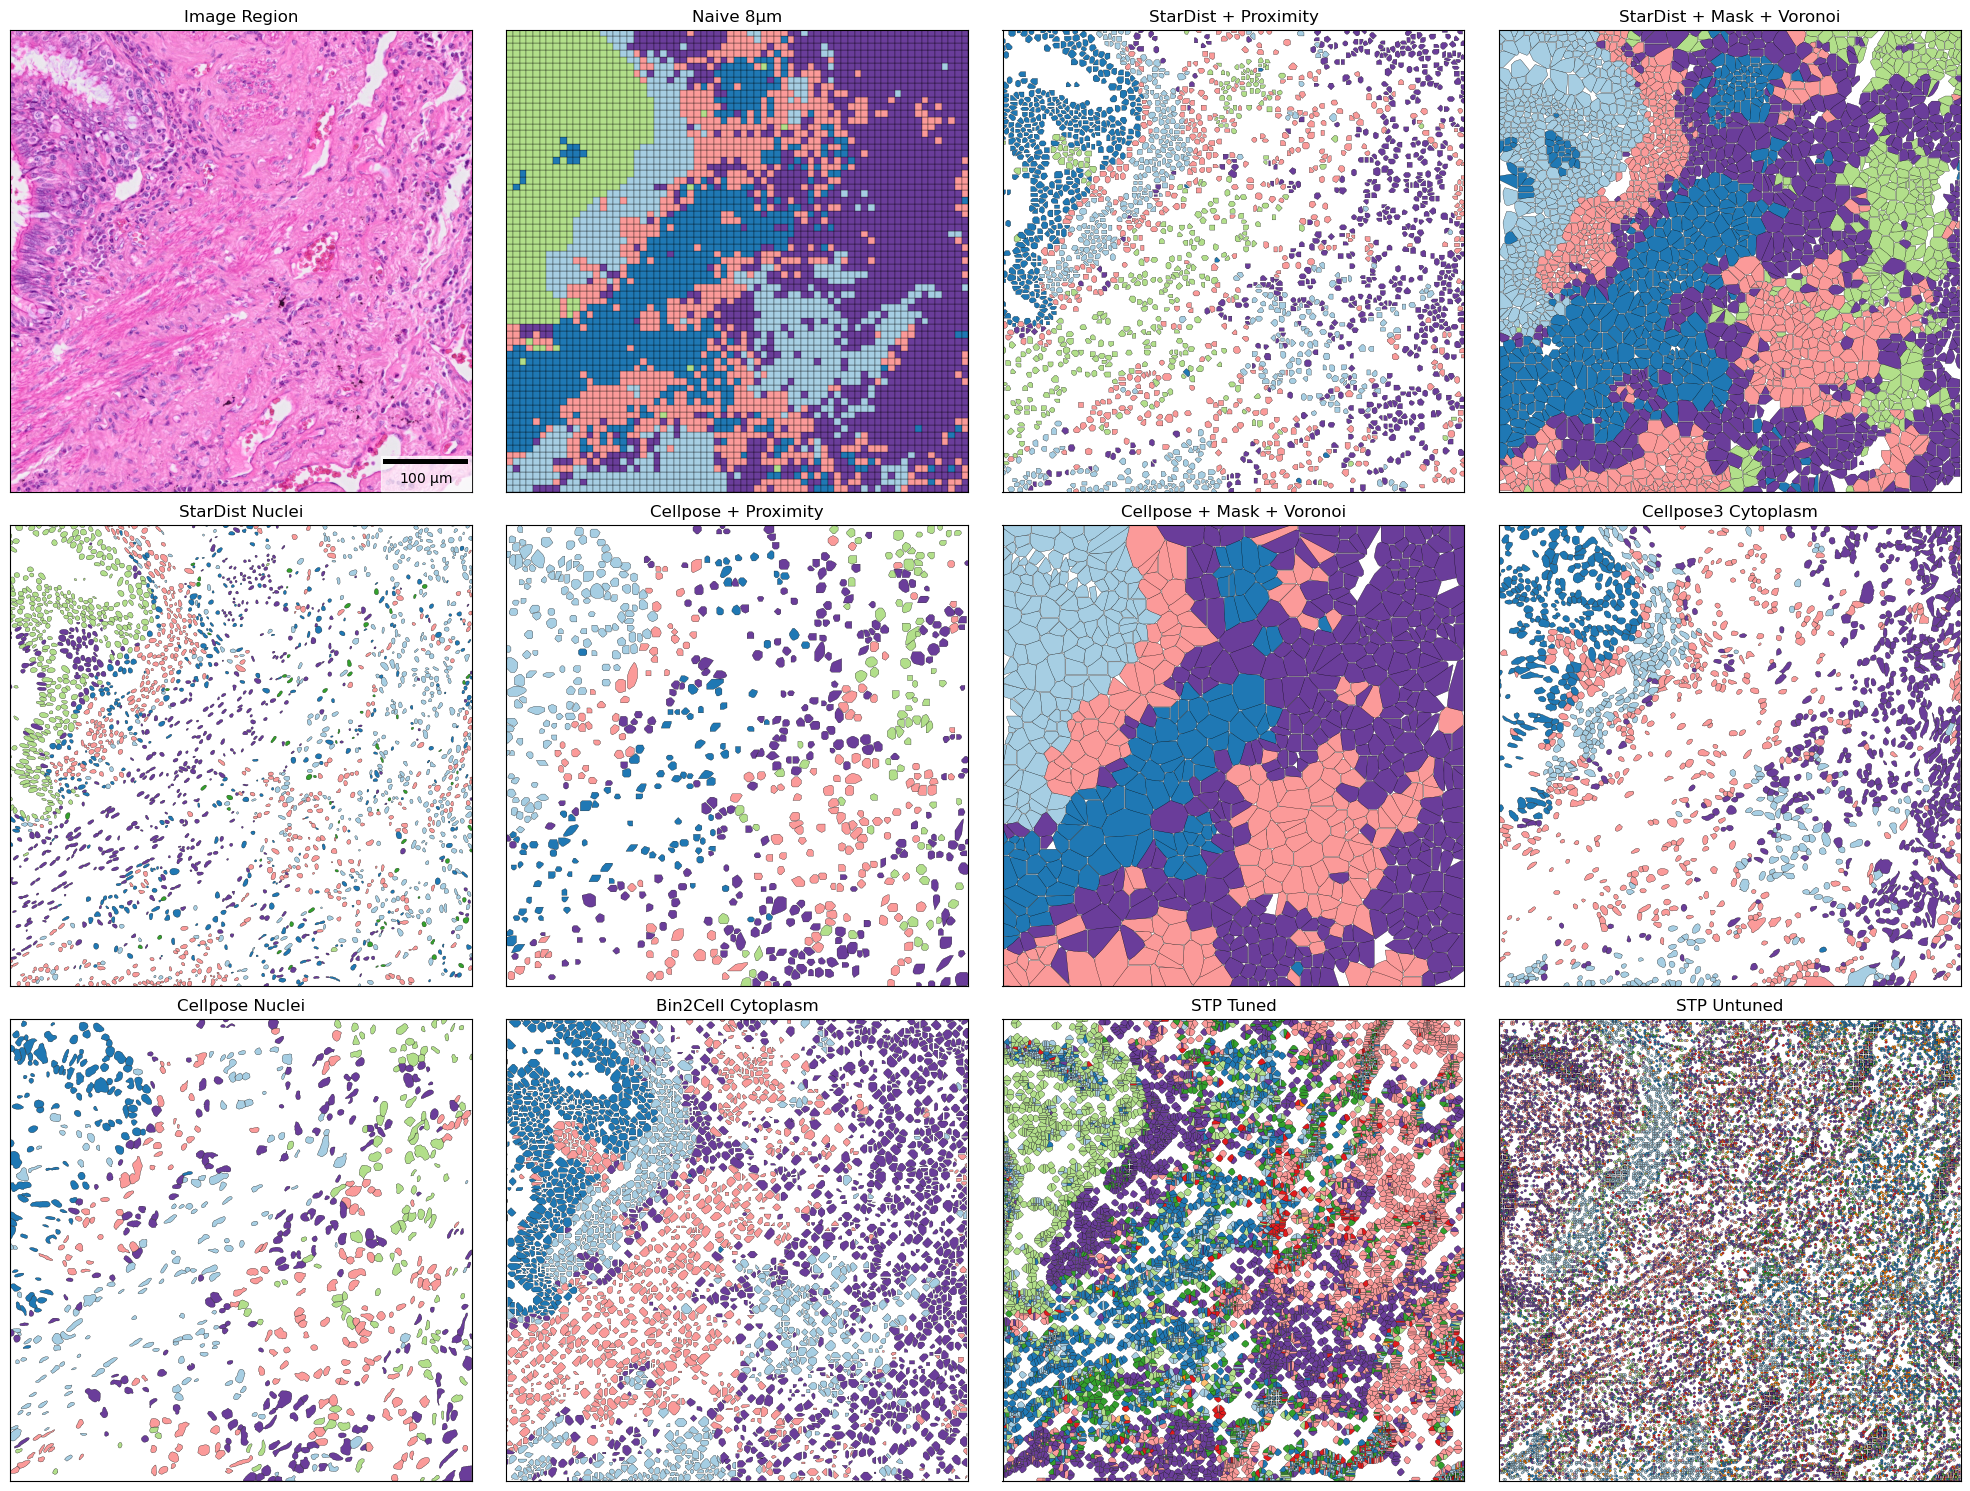

In [5]:
from matplotlib.colors import ListedColormap
import numpy as np

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes[0, 0].imshow(img_region, origin='lower')
axes[0, 0].set_title("Image Region")
axes[0, 0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

scalebar = ScaleBar(
    dx=microns_per_pixel,        
    units='µm',                  
    location='lower right',      
    scale_loc='bottom',         
    color='black',               
    box_alpha=0.7)               

axes[0, 0].add_artist(scalebar)

colors = [
    "#6a3d9a",
    "#fb9a99",
    "#a6cee3",
    "#1f78b4",
    "#b2df8a",
    "#33a02c",
    "#e31a1c",
    "#fdbf6f",
    "#ff7f00",
    "#cab2d6"]

# Get cluster frequency ranking across all GDFs
cluster_counts = {}
for gdf in data.values():
    for cluster_id, count in gdf['clusters'].value_counts().items():
        cluster_counts[cluster_id] = cluster_counts.get(cluster_id, 0) + count
        
sorted_clusters = sorted(cluster_counts.items(), key=lambda x: x[1], reverse=True)
cluster_to_idx = {cluster_id: i % len(colors) for i, (cluster_id, _) in enumerate(sorted_clusters)}

custom_cmap = ListedColormap(colors)

# Plot gdfs
for i, (key, gdf) in enumerate(data.items()):
    row, col = divmod(i + 1, 4)
    ax = axes[row, col]
    
    # Remap clusters to color indices based on frequency
    gdf_plot = gdf.copy()
    gdf_plot['cluster_color_idx'] = gdf_plot['clusters'].map(cluster_to_idx)
    
    gdf_plot.plot(column='cluster_color_idx', ax=ax, legend=False, edgecolor='black', 
                  linewidth=0.2, cmap=custom_cmap, vmin=0, vmax=len(colors)-1)
    ax.set_xlim(region_x[0], region_x[1])
    ax.set_ylim(region_y[0], region_y[1])
    ax.set_title(method_map.get(key, key))
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

for ax in axes.flat:
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('spatial_visual/human_lung_segmentation_comparison.pdf')
plt.show()